# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 30 marca 2026

Wybierz funkcję testową wykorzystaną w zadaniu 1.

Zadanie do oddania przez MS Teams. Do oddania: kod oraz krótkie sprawozdanie w PDF (można na przykład przy użyciu `quarto render notebook.ipynb --to pdf`).

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu. Zwróć uwagę, aby metoda wykonywała częściową optymalizację dla każdej wielkości parametru kary $\mu_k$ (wykonanie od 1 do 5 kroków dla ustalonej wartości parametru kary -- do samodzielnego wyboru).
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Wykorzystaj ponownie metodę optymalizacji z poprzedniego projektu. Jako funkcję celu i jej gradient przekaż funkcje uwzględniające karę (ogólny schemat):
```
function penalty_gradient_descent(f, f_grad, x0; ...)
    x_k = copy(x0)
    for i in 1:max_iter
        # dodać: wyliczanie współczynnika kary
        function penalized_f(x)
            # do uzupełnienia
        end
        function penalized_f_grad(x)
            # do uzupełnienia
        end
        x_k = gradient_descent(penalized_f, penalized_f_grad, x_k; max_iter=3)
    end
end
```
5. Przeprowadź procedurę dla kilkunastu kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych. Metoda ta powinna wykorzystywać przeszukiwanie w kierunku uwzględniające regułę Armijo.
3. Wraz ze zwiększaniem się parametru kary powinna maleć norma gradientu przy której kończymy działanie metody gradientów sprzężonych, na przykład może być równa $10^{-2} / \mu_k$. 

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.

Uwagi:

1. Dodanie typów w nagłówku metody przyspiesza kod tylko w rzadkich i bardzo szczególnych sytuacjach, i to tylko dla typów reprezentujących typy (`Core.Type`) lub funkcje.
2. Dobrym pomysłem jest wykonywanie operacji na tablicach w miejscu i unikanie alokacji. Warto też zwrócić uwagę na tzw. _type stability_, czyli unikanie sytuacji w których typ zmiennej zależy od wartości innej zmiennej.


In [5]:
import Pkg
Pkg.add(["Plots", "ForwardDiff"])
using LinearAlgebra, Plots, Random, ForwardDiff

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\jaros\.julia\environments\v1.12\Manifest.toml`


In [6]:
function three_hump_camel(x::AbstractVector)::Real
    return 2*x[1]^2 - 1.05*x[1]^4 + x[1]^6/6 + x[1]*x[2] + x[2]^2
end

function grad_three_hump_camel(x::AbstractVector)::Vector{Float64}
    return ForwardDiff.gradient(three_hump_camel, x)    
end

three_hump_domain = [-5.0, 5.0]

2-element Vector{Float64}:
 -5.0
  5.0

# Na 3.0

In [7]:
# Punkt 1: ograniczenie x1^2 + x2 + b = 0
# Dla Three Hump Camel minimum globalne jest w (0, 0), więc wybieramy b = 1.0,
# wtedy 0^2 + 0 + 1.0 = 1.0 != 0 i minimum nie spełnia ograniczenia.

const b_constraint = 1.0

constraint(x::AbstractVector, b::Float64=b_constraint) = x[1]^2 + x[2] + b
constraint_grad(x::AbstractVector) = [2.0 * x[1], 1.0]

x_min_thc = [0.0, 0.0]
println("Sprawdzenie ograniczenia w minimum Three Hump Camel: g([0,0]) = ", constraint(x_min_thc))

Sprawdzenie ograniczenia w minimum Three Hump Camel: g([0,0]) = 1.0


In [8]:
# Punkt 2: metoda funkcji kary z częściową optymalizacją dla każdego mu_k

function gradient_descent(f, f_grad, x0::AbstractVector; alpha::Float64=1e-3, max_iter::Int=100)
    x = copy(x0)
    x_hist = Vector{Vector{Float64}}()
    f_hist = Float64[]

    fx0 = f(x)
    if !isfinite(fx0)
        return x, f_hist, x_hist
    end

    push!(x_hist, copy(x))
    push!(f_hist, fx0)

    for _ in 1:max_iter
        g = f_grad(x)
        if !all(isfinite, g)
            break
        end

        x_new = x .- alpha .* g
        if !all(isfinite, x_new)
            break
        end

        fx_new = f(x_new)
        if !isfinite(fx_new)
            break
        end

        x = x_new
        push!(x_hist, copy(x))
        push!(f_hist, fx_new)
    end

    return x, f_hist, x_hist
end

function penalty_gradient_descent(f, f_grad, x0::AbstractVector;
    b::Float64=b_constraint,
    mu0::Float64=1.0,
    rho::Float64=1.5,
    outer_iter::Int=25,
    inner_steps::Int=4,
    alpha::Float64=1e-3)

    x = copy(x0)

    penalized_hist = Float64[]
    original_hist = Float64[]
    constraint_hist = Float64[]
    mu_hist = Float64[]

    # Stan początkowy
    first_mu = mu0
    g0 = constraint(x, b)
    p0 = f(x) + 0.5 * first_mu * g0^2
    if !isfinite(p0)
        return x, penalized_hist, original_hist, constraint_hist, mu_hist
    end

    push!(penalized_hist, p0)
    push!(original_hist, f(x))
    push!(constraint_hist, abs(g0))
    push!(mu_hist, first_mu)

    for k in 1:outer_iter
        mu_k = min(mu0 * rho^(k - 1), 1.0e6)

        # Definiuj funkcje z karą dla tego kroku
        local penalized_f, penalized_f_grad
        
        penalized_f = (xv) -> begin
            fval = f(xv)
            gval = constraint(xv, b)
            fval + 0.5 * mu_k * gval^2
        end

        penalized_f_grad = (xv) -> begin
            f_grad(xv) .+ mu_k * constraint(xv, b) .* constraint_grad(xv)
        end

        x_new, p_hist, x_hist = gradient_descent(
            penalized_f, penalized_f_grad, x;
            alpha=alpha, max_iter=inner_steps
        )

        if isempty(p_hist)
            break
        end

        # Dopisujemy historię krok po kroku (pomijamy punkt startowy segmentu)
        for j in 2:length(p_hist)
            xv = x_hist[j]
            push!(penalized_hist, p_hist[j])
            push!(original_hist, f(xv))
            push!(constraint_hist, abs(constraint(xv, b)))
            push!(mu_hist, mu_k)
        end

        x = x_new
    end

    return x, penalized_hist, original_hist, constraint_hist, mu_hist
end

penalty_gradient_descent (generic function with 1 method)

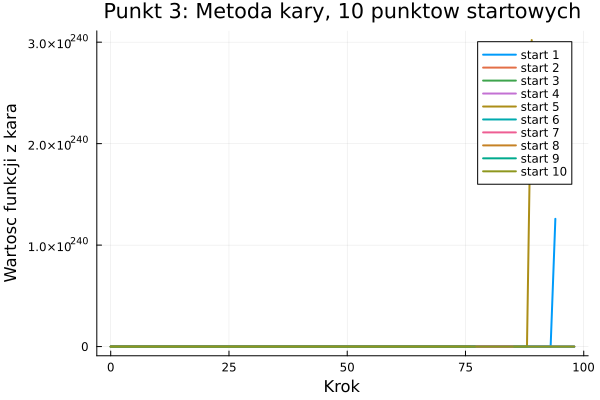

In [9]:
# Punkt 3: 10 losowych punktów, 100 kroków, wykres wartości funkcji od kroku

rand_uniform(a, b) = rand() * (b - a) + a

function run_penalty_experiments(f, f_grad, domain::AbstractVector{<:Real};
    n_points::Int=10,
    total_steps::Int=100,
    inner_steps::Int=4,
    alpha::Float64=5e-4,
    b::Float64=b_constraint,
    mu0::Float64=1.0,
    rho::Float64=1.5,
    seed::Int=42)

    Random.seed!(seed)

    outer_iter = cld(total_steps, inner_steps)
    starts = [[rand_uniform(domain[1], domain[2]), rand_uniform(domain[1], domain[2])] for _ in 1:n_points]

    histories_pen = Vector{Vector{Float64}}()
    histories_orig = Vector{Vector{Float64}}()
    histories_constr = Vector{Vector{Float64}}()

    for x0 in starts
        _, h_pen, h_orig, h_constr, _ = penalty_gradient_descent(
            f, f_grad, x0;
            b=b, mu0=mu0, rho=rho,
            outer_iter=outer_iter, inner_steps=inner_steps, alpha=alpha
        )
        if !isempty(h_pen)
            push!(histories_pen, h_pen[1:min(end, total_steps + 1)])
            push!(histories_orig, h_orig[1:min(end, total_steps + 1)])
            push!(histories_constr, h_constr[1:min(end, total_steps + 1)])
        end
    end

    return starts, histories_pen, histories_orig, histories_constr
end

starts, histories_pen, histories_orig, histories_constr = run_penalty_experiments(
    three_hump_camel, grad_three_hump_camel, three_hump_domain;
    n_points=10, total_steps=100, inner_steps=4,
    alpha=0.0005, b=b_constraint, mu0=1.0, rho=1.5, seed=42
)

p = plot(
    title="Punkt 3: Metoda kary, 10 punktow startowych",
    xlabel="Krok",
    ylabel="Wartosc funkcji z kara",
    legend=:topright
)

for i in 1:length(histories_pen)
    plot!(p, 0:length(histories_pen[i]) - 1, histories_pen[i], label="start $i", lw=2)
end

display(p)

In [10]:
# Punkt 4: jawne przekazanie penalized_f i penalized_f_grad do gradient_descent

x0_demo = [2.5, -3.0]
mu_demo = 10.0

penalized_f_demo(x) = three_hump_camel(x) + 0.5 * mu_demo * constraint(x, b_constraint)^2
penalized_f_grad_demo(x) = grad_three_hump_camel(x) .+ mu_demo * constraint(x, b_constraint) .* constraint_grad(x)

x_after, hist_after, _ = gradient_descent(
    penalized_f_demo,
    penalized_f_grad_demo,
    x0_demo;
    alpha=0.001,
    max_iter=3
)

println("Punkt 4: przykład 3 kroków gradient_descent na funkcji z karą")
println("x0 = ", x0_demo)
println("x_po_3_krokach = ", x_after)
println("historia P(x) = ", hist_after)

Punkt 4: przykład 3 kroków gradient_descent na funkcji z karą
x0 = [2.5, -3.0]
x_po_3_krokach = [1.9921469694578735, -3.0846293336646644]
historia P(x) = [103.98697916666666, 52.7124490455571, 32.838030714732184, 22.934998501933343]


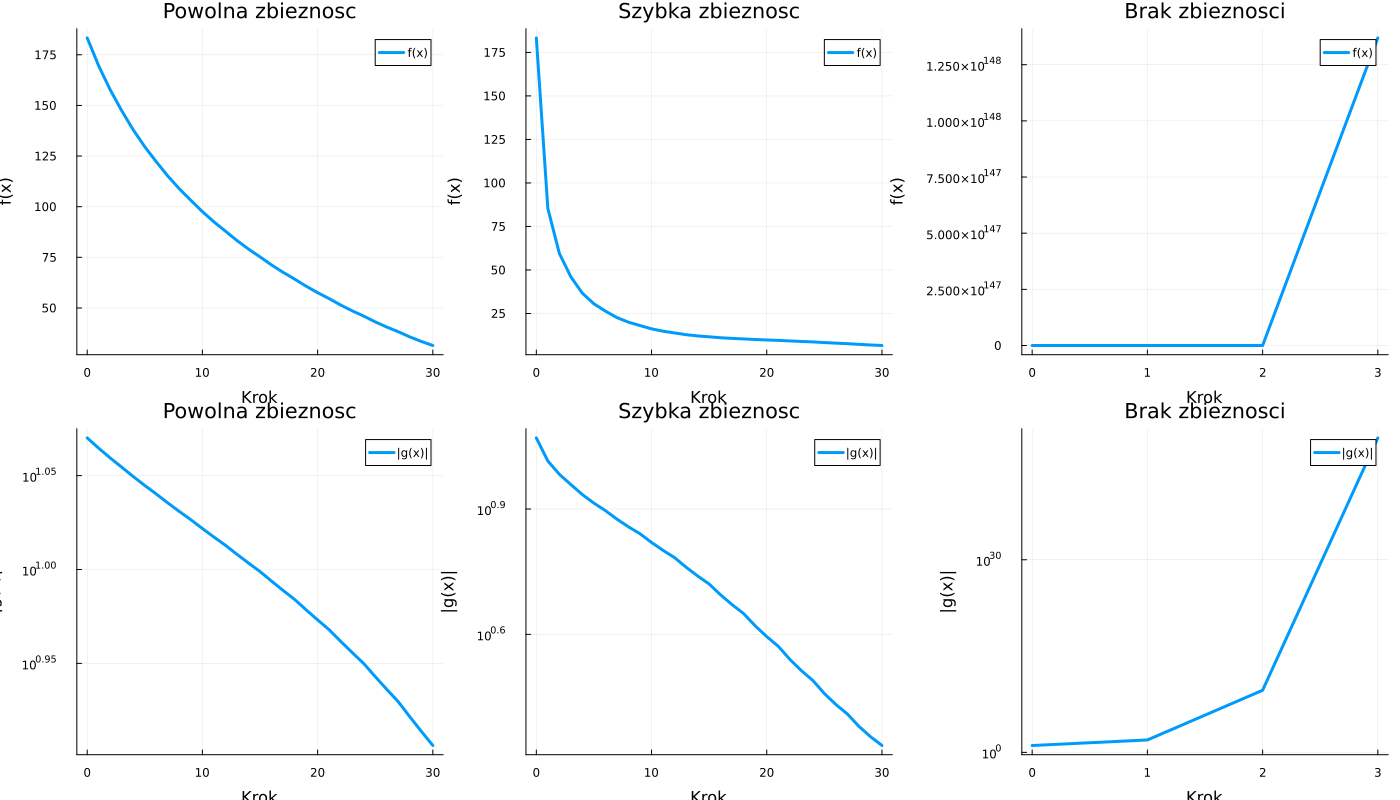

In [11]:
# Punkt 5: ilustracja powolnej, szybkiej i braku zbieżności - rysuj f(x) i |g(x)|

using Statistics

function convergence_analysis(f, f_grad, domain::AbstractVector{<:Real};
    n_points::Int=10,
    total_steps::Int=30,
    inner_steps::Int=3,
    alpha::Float64=1e-3,
    mu0::Float64=1.0,
    rho::Float64=2.0,
    seed::Int=7)

    _, _, histories_f, histories_g = run_penalty_experiments(
        f, f_grad, domain;
        n_points=n_points,
        total_steps=total_steps,
        inner_steps=inner_steps,
        alpha=alpha,
        b=b_constraint,
        mu0=mu0,
        rho=rho,
        seed=seed
    )

    histories_f_nonempty = [h for h in histories_f if !isempty(h)]
    histories_g_nonempty = [h for h in histories_g if !isempty(h)]
    
    if isempty(histories_f_nonempty) || isempty(histories_g_nonempty)
        return [NaN], [NaN]
    end

    n = minimum(length.(histories_f_nonempty))
    avg_f = [mean([histories_f_nonempty[i][k] for i in 1:length(histories_f_nonempty)]) for k in 1:n]
    avg_g = [mean([histories_g_nonempty[i][k] for i in 1:length(histories_g_nonempty)]) for k in 1:n]
    
    return avg_f, avg_g
end

configs = [
    ("Powolna zbieznosc", 0.00005, 1.3),
    ("Szybka zbieznosc",  0.00050, 1.5),
    ("Brak zbieznosci",   0.02000, 2.0)
]

plots_f = Any[]
plots_g = Any[]

for (name, alpha, rho) in configs
    avg_f, avg_g = convergence_analysis(
        three_hump_camel, grad_three_hump_camel, three_hump_domain;
        n_points=10, total_steps=30, inner_steps=3,
        alpha=alpha, mu0=1.0, rho=rho, seed=7
    )

    # Wykres f(x)
    p_f = plot(
        0:length(avg_f)-1,
        avg_f,
        lw=3,
        label="f(x)",
        title=name,
        xlabel="Krok",
        ylabel="f(x)",
        legend=:topright
    )
    push!(plots_f, p_f)

    # Wykres |g(x)|
    p_g = plot(
        0:length(avg_g)-1,
        avg_g,
        lw=3,
        label="|g(x)|",
        title=name,
        xlabel="Krok",
        ylabel="|g(x)|",
        legend=:topright,
        yscale=:log10
    )
    push!(plots_g, p_g)
end

# Łącz wykresy: f(x) w górnym wierszu, |g(x)| w dolnym
combined = [plots_f[1], plots_f[2], plots_f[3],
            plots_g[1], plots_g[2], plots_g[3]]
plot(combined..., layout=(2, 3), size=(1400, 800))